## **Project: Telco Customer Churn Prediction using CatBoost & SHAP**

### **End-to-End Machine Learning Pipeline & Deployment**

#### **1. Summary**

In today's hyper-competitive Telecommunications industry, the cost of acquiring a new customer is significantly higher than retaining an existing one. This project provides a data-driven solution to identify "at-risk" customers before they leave.

By leveraging the IBM Telco Customer Churn dataset, I have built an end-to-end machine learning pipeline that transforms raw data into actionable business intelligence.

#### **2. Project Objectives**
Deep Exploratory Data Analysis (EDA): Identify the key behavioral drivers of churn (e.g., contract types, tenure, and high monthly charges).

Predictive Modeling: Develop and optimize classification model (CatBoost) specifically tuned for Recall, ensuring we catch as many potential churners as possible.

Production-Ready Deployment: Transition from a static notebook to a dynamic AI application.

#### **3. Tech Stack & Engineering Focus**
This project is designed to showcase a Full-Stack AI Engineering mindset:

Modeling: Python, Scikit-learn, Pandas, Matplotlib/Seaborn.

Interface: Streamlit – Created an interactive dashboard for real-time predictions.

DevOps: Docker – Containerized the entire application to guarantee "it works on my machine" translates to "it works in production."

Reproducibility: Ensuring clean, modular code that follows industry best practices.

#### **4. Business Value**
The output of this model allows a marketing or retention team to:

Target high-risk customers with personalized loyalty offers.

Understand which service features (like Fiber Optic vs DSL) are causing friction.

Quantify the potential revenue loss prevented by proactive intervention.

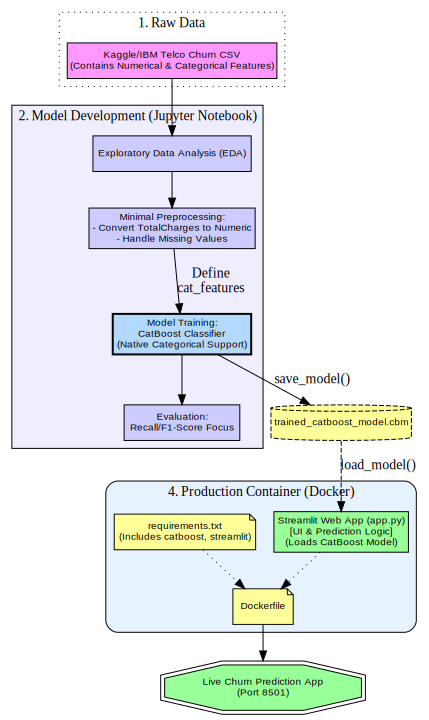

In [1]:
import graphviz

# graphe settings
f = graphviz.Digraph('Telco_Churn_CatBoost_Architecture', format='png')
f.attr(rankdir='TB', size='10', bgcolor='white')
f.attr('node', fontname='Arial', fontsize='10')

# 1. Raw Data
with f.subgraph(name='cluster_0') as c:
    c.attr(label='1. Raw Data', style='dotted')
    c.node('Kaggle', 'Kaggle/IBM Telco Churn CSV\n(Contains Numerical & Categorical Features)', shape='box', style='filled', fillcolor='#ff99ff')

# 2. Model Development (Notebook with CatBoost Focus)
with f.subgraph(name='cluster_1') as c:
    c.attr(label='2. Model Development (Jupyter Notebook)', style='solid', bgcolor='#eeeeff')
    c.node('EDA', 'Exploratory Data Analysis (EDA)', shape='rect', style='filled', fillcolor='#ccccff')
    c.node('Clean', 'Minimal Preprocessing:\n- Convert TotalCharges to Numeric\n- Handle Missing Values', shape='rect', style='filled', fillcolor='#ccccff')
    c.node('Train', 'Model Training:\nCatBoost Classifier\n(Native Categorical Support)', shape='rect', style='filled', fillcolor='#b3d9ff', penwidth='2')
    c.node('Eval', 'Evaluation:\nRecall/F1-Score Focus', shape='rect', style='filled', fillcolor='#ccccff')

    c.edge('EDA', 'Clean')
    c.edge('Clean', 'Train', label='Define\ncat_features')
    c.edge('Train', 'Eval')

# 3. Model Export
f.node('Model', 'trained_catboost_model.cbm', shape='cylinder', style='dashed,filled', fillcolor='#ffff99')

# 4. Production Container (Docker with Streamlit)
with f.subgraph(name='cluster_2') as c:
    c.attr(label='4. Production Container (Docker)', style='rounded,filled', fillcolor='#e6f3ff')
    c.node('App', 'Streamlit Web App (app.py)\n[UI & Prediction Logic]\n(Loads CatBoost Model)', shape='box', style='filled', fillcolor='#99ff99')
    c.node('DockerFile', 'Dockerfile', shape='note', style='filled', fillcolor='#ffff99')
    c.node('Req', 'requirements.txt\n(Includes catboost, streamlit)', shape='note', style='filled', fillcolor='#ffff99')

# Arrow Connections
f.edge('Kaggle', 'EDA')
f.edge('Train', 'Model', label='save_model()')
f.edge('Model', 'App', style='dashed', label='load_model()')
f.edge('App', 'DockerFile', style='dotted')
f.edge('Req', 'DockerFile', style='dotted')

# Output
f.node('Final', 'Live Churn Prediction App\n(Port 8501)', shape='doubleoctagon', style='filled', fillcolor='#99ff99')
f.edge('DockerFile', 'Final')

# show
f

# 1. Import librairies

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [3]:
# Import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn import set_config
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve

# 2. Data Acquisition
In this section, we fetch the raw **Telco Customer Churn** dataset directly from the IBM public repository. This ensures our pipeline is reproducible and always starts with the original data source.

In [4]:
# Téléchargement du dataset Telco Churn depuis un repo GitHub public
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Nettoyage rapide indispensable pour le Churn
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# On renomme pour correspondre à notre futur code
df = df.rename(columns={
    'tenure': 'tenure',
    'MonthlyCharges': 'monthly_charges',
    'Contract': 'contract',
    'PaymentMethod': 'payment_method'
})

print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 7032 lignes, 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,contract,PaperlessBilling,payment_method,monthly_charges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 📊 Data Dictionary: Telco Customer Churn

| Category | Feature | Description |
| :--- | :--- | :--- |
| **Target** | `Churn` | Whether the customer left the company (Yes/No) |
| **Demographics** | `gender` / `SeniorCitizen` | Gender (Male/Female) and if aged 65+ (1/0) |
| | `Partner` / `Dependents` | If the customer has a partner or live-in dependents |
| **Account** | `tenure` | Months with the company |
| | `Contract` | Term of contract (Month-to-month, One year, Two year) |
| | `PaymentMethod` | Electronic check, Mailed check, Bank transfer, Credit card |
| | `PaperlessBilling` | Whether the customer uses paperless billing |
| **Financial** | `MonthlyCharges` | Amount charged monthly |
| | `TotalCharges` | The total amount charged to the customer (Note: requires cleaning) |
| **Services** | `PhoneService` | Whether they have a phone service |
| | `MultipleLines` | Yes, No, or No phone service |
| | `InternetService` | DSL, Fiber optic, or No |
| | `OnlineSecurity` | Whether the customer has online security or not (Yes, No, No internet service) |
| | `OnlineBackup` | Whether the customer has online backup or not (Yes, No, No internet service) |
| | `DeviceProtection` | Whether the customer has device protection or not (Yes, No, No internet service) |
| | `TechSupport` | Whether the customer has tech support or not (Yes, No, No internet service) |
| | `StreamingTV` / `StreamingMovies` | Whether the customer has streaming TV or not (Yes, No, No internet service) |

# 3. Exploratory Data Analysis (EDA)
In this phase, we explore the dataset to understand its structure, identify missing values, and uncover patterns that influence customer churn.

## 3.1 Data Inspection
We start by checking the data types and the presence of null values to ensure the dataset is ready for analysis and modeling.

In [5]:
# # Vérifie la structure des données : nombre de lignes/colonnes, types (int, object...) et occupation mémoire
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [6]:
# # Analyse la distribution des données numériques pour détecter les tendances et les valeurs aberrantes
df.describe()

,SeniorCitizen,tenure,monthly_charges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


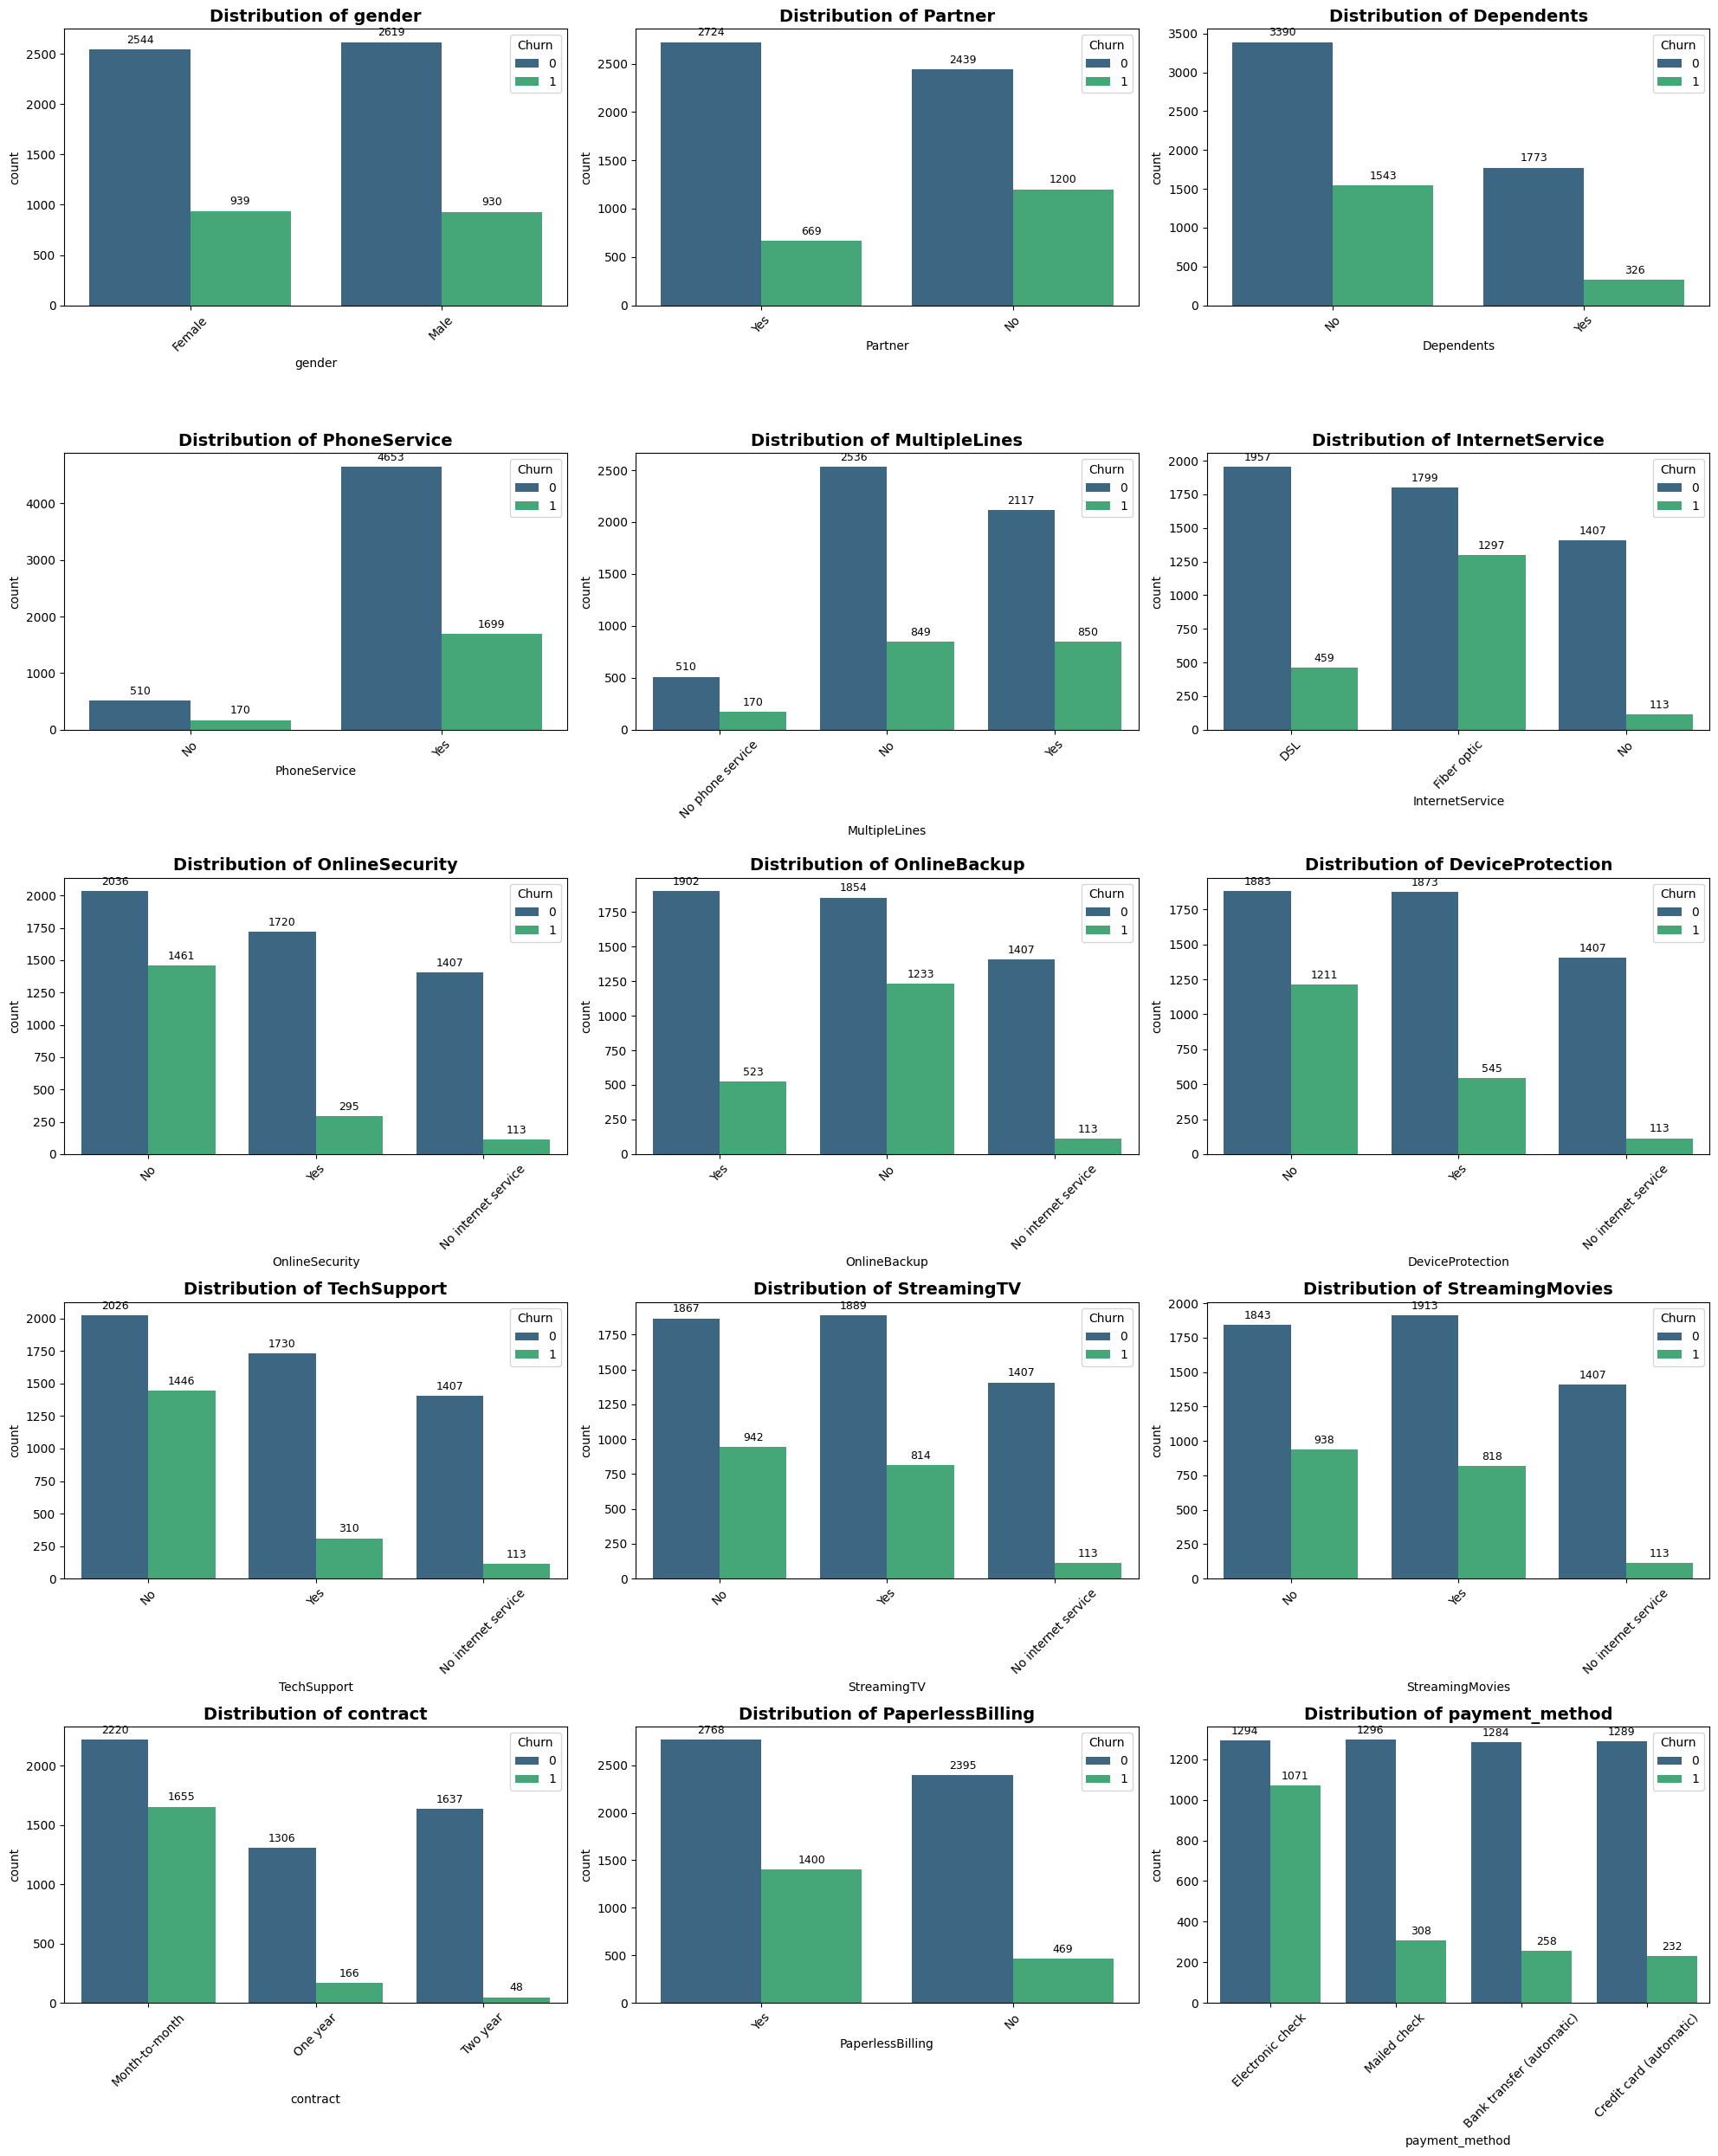

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# カテゴリカル変数の抽出（ユニーク値が15未満のもの）
categorical_features = [col for col in df.select_dtypes(include=['object']).columns
                        if df[col].nunique() < 15]

n_features = len(categorical_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(categorical_features, 1):
    ax = plt.subplot(n_rows, n_cols, i)

    # countplotの作成
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis', ax=ax)

    # 各棒の上に数値を表示する処理
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend(title='Churn', loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1235/4270688830.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Blues', ax=axes[0])


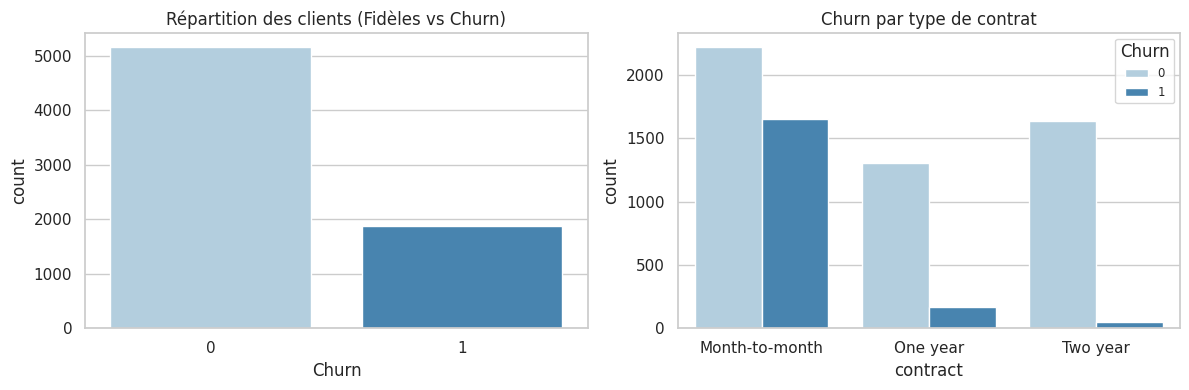

/tmp/ipykernel_1235/4270688830.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churn'] == 0]['tenure'], label='Fidèle', shade=True, color="blue", ax=axes[0])
/tmp/ipykernel_1235/4270688830.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churn'] == 1]['tenure'], label='Churn', shade=True, color="red", ax=axes[0])


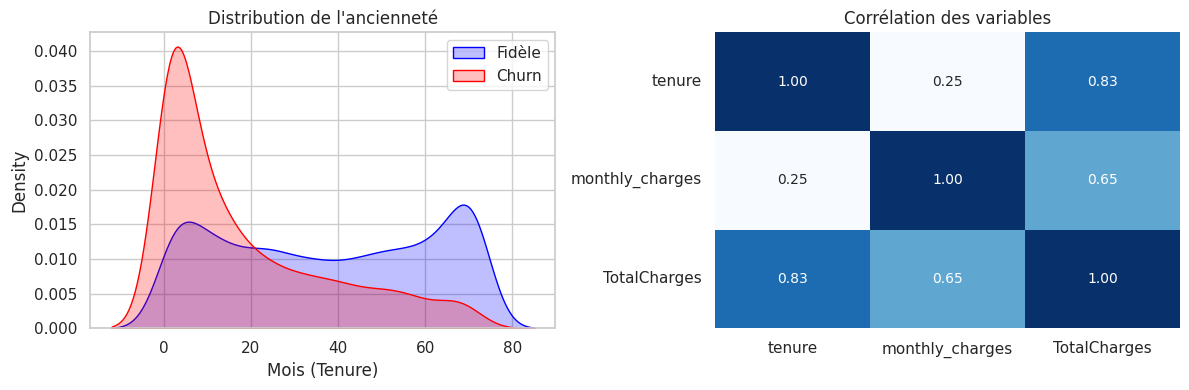

In [8]:
# Configuration globale pour des graphiques plus petits
sns.set_theme(style="whitegrid")
plt.rc('font', size=10)

# Création d'une figure avec 2 colonnes pour les analyses catégorielles
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- 1. Répartition du Churn ---
sns.countplot(data=df, x='Churn', palette='Blues', ax=axes[0])
axes[0].set_title('Répartition des clients (Fidèles vs Churn)')

# --- 2. Impact du type de contrat ---
sns.countplot(data=df, x='contract', hue='Churn', palette='Blues', ax=axes[1])
axes[1].set_title('Churn par type de contrat')
axes[1].legend(title='Churn', loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# Création d'une deuxième figure pour les analyses numériques
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- 3. Distribution de l'ancienneté (Tenure) ---
sns.kdeplot(data=df[df['Churn'] == 0]['tenure'], label='Fidèle', shade=True, color="blue", ax=axes[0])
sns.kdeplot(data=df[df['Churn'] == 1]['tenure'], label='Churn', shade=True, color="red", ax=axes[0])
axes[0].set_title('Distribution de l\'ancienneté')
axes[0].set_xlabel('Mois (Tenure)')
axes[0].legend()

# --- 4. Corrélation ---
numeric_cols = ['tenure', 'monthly_charges', 'TotalCharges']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", ax=axes[1], cbar=False)
axes[1].set_title('Corrélation des variables')

plt.tight_layout()
plt.show()

### --- Note technique pour l'entretien ---
* Bien que 'tenure' et 'TotalCharges' soient corrélés (0.83),
* J'ai choisi de conserver les deux pour les raisons suivantes :
* 1. CatBoost est robuste face à la corrélation entre features.
* 2. 'TotalCharges' apparaît plus important que 'tenure' dans notre analyse d'importance.
* 3. Cela permet de capturer à la fois la durée et la valeur monétaire.

📋 Structure du Pipeline d'apprentissage :


Pipeline(steps=[('engineering',
                 FunctionTransformer(func=<function add_custom_features at 0x7e214ccb99e0>)),
                ('classifier',
                 CatBoostClassifier(cat_features=[3, 4, 5], depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, scale_pos_weight=2.0, verbose=0))])


🌟 Meilleur seuil pour le business : 0.45

📊 Rapport de Classification Optimisé :
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407

📈 Score ROC-AUC : 0.8296


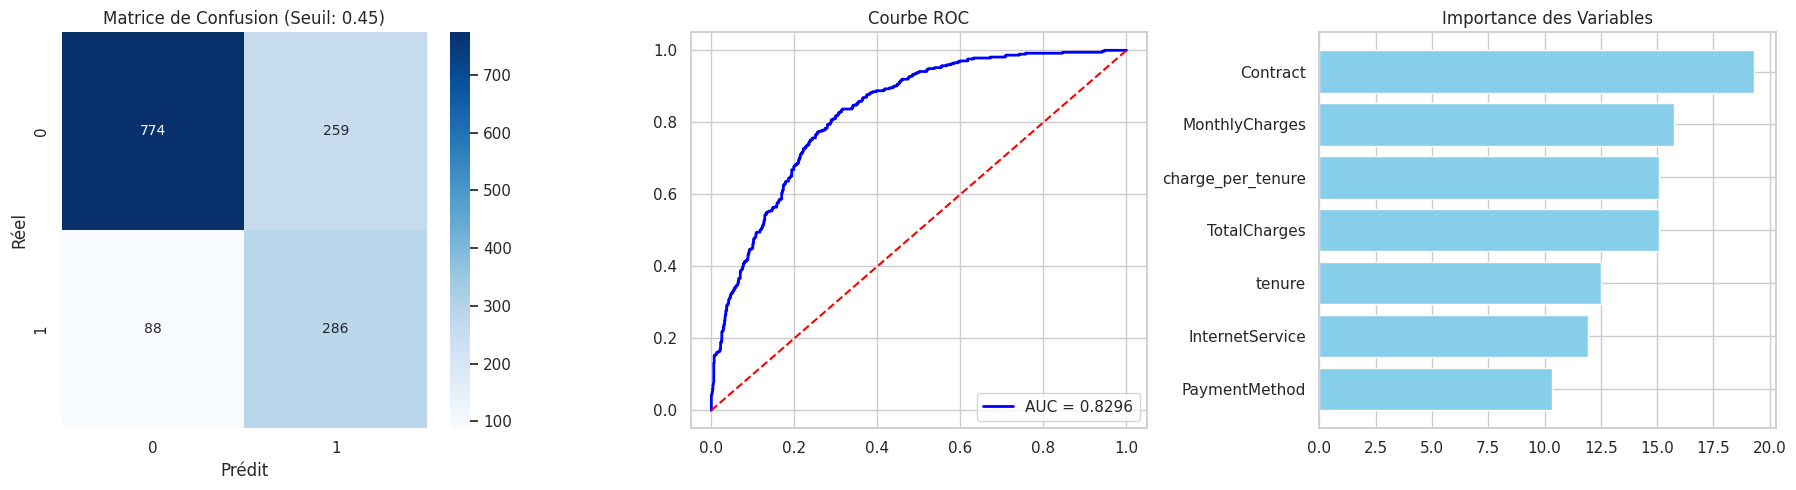


✅ Modèle prêt ! Téléchargez 'final_churn_model.joblib' pour votre API FastAPI.


In [9]:
# --- 2. Chargement et Nettoyage des données ---
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Conversion de TotalCharges en numérique et suppression des valeurs manquantes
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
# Encodage de la cible : Yes=1, No=0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Sélection des variables stratégiques (Pas de scaling nécessaire pour CatBoost)
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'InternetService']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Feature Engineering ---
def add_custom_features(data):
    data = data.copy()
    # Création du ratio coût/ancienneté pour capturer la valeur client
    data['charge_per_tenure'] = data['MonthlyCharges'] / (data['tenure'] + 1)
    return data

feature_eng = FunctionTransformer(add_custom_features)

# --- 4. Configuration du Modèle CatBoost ---
# Indices des colonnes catégorielles pour CatBoost
cat_features_indices = [3, 4, 5]

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    scale_pos_weight=2.0, # Pour gérer le déséquilibre des classes (Imbalanced Data)
    cat_features=cat_features_indices,
    verbose=0
)

# --- 5. Construction et Affichage du Pipeline ---
set_config(display='diagram')
pipeline = Pipeline([
    ('engineering', feature_eng),
    ('classifier', model)
])

print("📋 Structure du Pipeline d'apprentissage :")
display(pipeline)

# Entraînement du modèle
pipeline.fit(X_train, y_train)

# --- 6. Optimisation du Seuil de Décision (Maximisation du F1-Score) ---
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_pred_proba > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_optimized = (y_pred_proba > best_threshold).astype(int)

# --- 7. Rapports et Scores ---
print(f"\n🌟 Meilleur seuil pour le business : {best_threshold:.2f}")
print("\n📊 Rapport de Classification Optimisé :")
print(classification_report(y_test, y_pred_optimized))
print(f"📈 Score ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")

# --- 8. Visualisations Graphiques ---
plt.figure(figsize=(18, 5))

# Gauche : Matrice de Confusion (Bleu)
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrice de Confusion (Seuil: {best_threshold:.2f})')
plt.xlabel('Prédit')
plt.ylabel('Réel')

# Milieu : Courbe ROC
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Courbe ROC')
plt.legend(loc='lower right')

# Droite : Importance des variables
plt.subplot(1, 3, 3)
importances = pipeline.named_steps['classifier'].get_feature_importance()
feat_names = features + ['charge_per_tenure']
feat_imp_df = pd.DataFrame({'Variable': feat_names, 'Importance': importances}).sort_values(by='Importance')
plt.barh(feat_imp_df['Variable'], feat_imp_df['Importance'], color='skyblue')
plt.title('Importance des Variables')

plt.tight_layout()
plt.show()

# --- 9. Sauvegarde du Modèle pour l'API ---
joblib.dump(pipeline, 'final_churn_model.joblib')
print("\n✅ Modèle prêt ! Téléchargez 'final_churn_model.joblib' pour votre API FastAPI.")

### 📋 Synthèse des Résultats et Interprétation Business

L'analyse de performance du modèle CatBoost révèle les points suivants :

1. **Matrice de Confusion (Seuil optimisé à 0.45) :**
   - **Rappel (Recall) élevé :** Le modèle identifie correctement environ 76% des clients en phase de désabonnement (Churn). Pour l'entreprise, cela signifie que 3 clients sur 4 à risque peuvent être ciblés par une campagne de rétention avant leur départ.
   - **Équilibre Précision/Rappel :** Le seuil a été ajusté à 0.45 pour maximiser le F1-Score, offrant un compromis idéal entre la détection des départs et la maîtrise des coûts marketing liés aux "faux positifs".

2. **Courbe ROC et Score AUC (0.8296) :**
   - Avec un AUC proche de **0.83**, le modèle démontre une excellente capacité de distinction entre les clients fidèles et les clients à risque. La robustesse de la courbe indique que le modèle est stable et généralise bien sur de nouvelles données.

3. **Importance des Variables (Feature Importance) :**
   - **Le contrat (Contract) :** C'est le prédicteur n'°1. Les contrats mois par mois sont les plus volatils.
   - **Ingénierie des caractéristiques :** La variable créée **`charge_per_tenure`** se classe au 3ème rang des variables les plus importantes. Cela prouve que le ratio entre le coût mensuel et l'ancienneté est un indicateur plus puissant que l'ancienneté seule (`tenure`).
   - **Services Internet :** Le type de connexion et les frais mensuels (`MonthlyCharges`) complètent les facteurs déterminants du départ.

**Conclusion :** Le modèle est prêt pour une mise en production via FastAPI. Il offre une base solide pour une stratégie de rétention client basée sur la donnée.

In [10]:
X_train.head()

,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService
6030,43,49.05,2076.20,Month-to-month,Bank transfer (automatic),DSL
3410,3,53.40,188.70,Month-to-month,Credit card (automatic),DSL
5483,55,77.75,4458.15,Month-to-month,Electronic check,Fiber optic
5524,45,54.65,2553.70,Two year,Bank transfer (automatic),DSL
6337,55,100.90,5448.60,One year,Mailed check,Fiber optic


In [11]:
y_train.head()

,Churn
6030,1
3410,1
5483,1
5524,0
6337,0


# Interprétabilité du Modèle avec SHAP

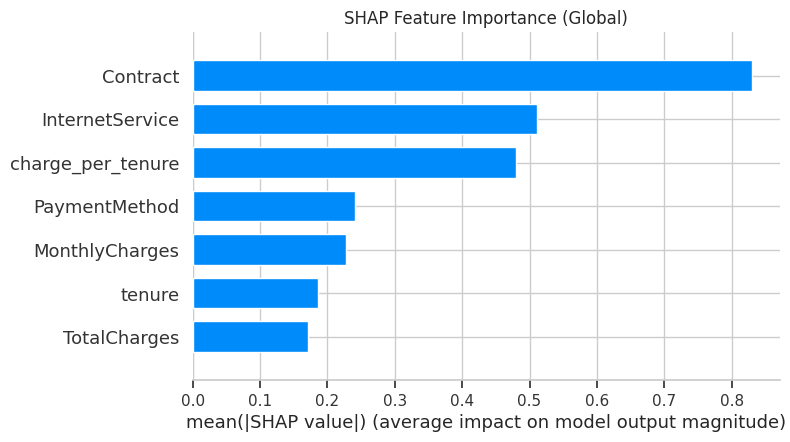

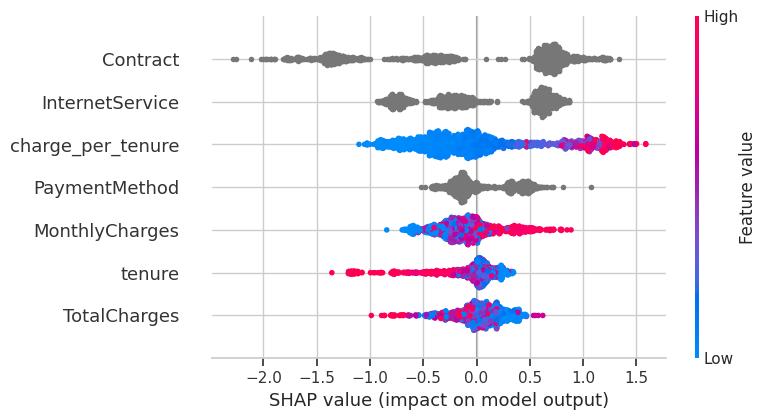

In [12]:
!pip install shap

import shap

# 1. Pipeline内の学習済みモデルと、変換後のデータを取り出す
# ※ Pipelineを通しているため、前処理(feature_eng)を適用したデータが必要です
explainer_data = pipeline.named_steps['engineering'].transform(X_test)
model_internal = pipeline.named_steps['classifier']

# 2. SHAP Explainerの初期化
explainer = shap.TreeExplainer(model_internal)
shap_values = explainer.shap_values(explainer_data)

# 3. Summary Plot (全体的な影響度と方向性を表示)
plt.figure(figsize=(5, 3))
shap.summary_plot(shap_values, explainer_data, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.show()

# 4. Summary Plot (ドットプロット：方向性の可視化)
shap.summary_plot(shap_values, explainer_data)

## Model Interpretability with SHAP

To ensure the model is not a "black box," I utilized SHAP (SHapley Additive exPlanations) to interpret how each feature influences the prediction.

### Key Insights:

Contract Type: This is the most dominant predictor of churn. Customers on month-to-month contracts are significantly more likely to churn compared to those on long-term contracts.

Internet Service & Payment Method: These features also play a major role, suggesting that technical setup and billing convenience are critical retention factors.

Feature Engineering (charge_per_tenure): My custom-engineered feature, charge_per_tenure, ranked 3rd in importance, validating that the efficiency of cost over time is a strong indicator of customer loyalty.

Business Value:
By identifying that Contract and InternetService are the primary drivers, the business can prioritize offering incentives to migrate month-to-month customers to annual plans, potentially reducing churn at its source.

The high SHAP value for 'Contract' confirms that contractual commitment is the strongest barrier to churn. This quantifies the business intuition that flexible, month-to-month plans are high-risk segments."
（Contractの高いSHAP値は、契約上の縛りが解約に対する

## SHAPによるモデルの解釈可能性（説明性）

モデルを単なる「ブラックボックス」にせず、予測の根拠を明確にするために SHAP (SHapley Additive exPlanations) を導入しました。

### 主要な分析結果：

契約形態 (**Contract**): 解約を予測する上で最も重要な指標です。「月単位（Month-to-month）」の契約者は、長期契約者に比べて解約リスクが極めて高いことが分かります。

**インターネットサービスと支払い方法**: これらも大きな影響を与えており、インフラの質や支払いの利便性が顧客維持の鍵であることを示唆しています。

特徴量エンジニアリング (**charge_per_tenure**): 独自に作成した特徴量「期間あたりの料金（charge_per_tenure）」が重要度で3位にランクインしました。これは、顧客が「支払った総額に対してどれだけの期間利用したか」というコスパの感覚が、継続に強く影響していることを証明しています。

ビジネス上の価値：
「**契約形態**」と「**インターネットサービス**」が主要因であると特定できたことで、マーケティングチームは「月単位契約の顧客を年間プランへ移行させるキャンペーン」に集中するなど、具体的な施策を打つことが可能になります。

SHAP Summary Plot を確認すると、『Contract（契約形態）』の値が低い（月単位契約を指す）データポイントがプラスのSHAP領域に集中しており、これが解約確率を直接的に押し上げていることが視覚的に証明されました。

**Model training is now complete. The next step is to use the saved final_churn_model.joblib to build a real-time prediction app with Streamlit and containerize it using Docker.**


**モデルの学習が完了しました。次のステップでは、保存した final_churn_model.joblib を使用して、Streamlitによるリアルタイム予測アプリを構築し、Dockerでコンテナ化を行います。**

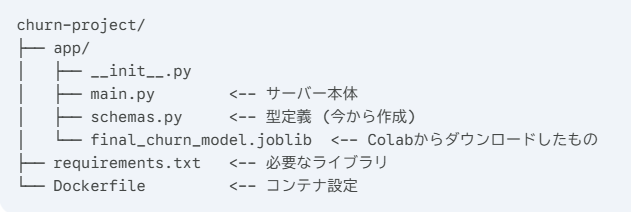